# 06. How LLMs Work

**Tier:** Foundations
**Estimated time:** 50 minutes
**Prerequisites:** 00–05
**Source material:** @sairahul1 — "20 AI Concepts You Must Understand in 2026"; @hesamation on LLMs as compression

## What You'll Learn
- The one-sentence truth: an LLM is a **next-token predictor**, and generation is that prediction run in a loop
- How **temperature** and **top-k / top-p** sampling reshape the probability distribution to trade off boring vs. creative
- What the **context window** is and why it bounds everything
- *Why models hallucinate* — and why that's a direct consequence of how they work, not a bug to patch

## Why This Matters
This notebook connects everything in Tier 1. The architecture (05) produces logits; this is where logits become text. Understanding that the model predicts *plausible* tokens, not *true* ones, is the single most important mental model for using LLMs well — and it's the entire motivation for RAG (notebook 14) and evals (notebook 24).

In [ ]:
import os

# Load .env if python-dotenv is installed; harmless if it isn't.
# Not required for this notebook (runs fully offline with transformers/PyTorch).
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

## Autocomplete on steroids

Strip away the mystique and an LLM does exactly one thing: **given a sequence of tokens, predict a probability distribution over the next token.** That's the logits → softmax you built in notebook 05.

To generate text, you run that prediction in a loop:
1. Feed the prompt, get a distribution over the next token.
2. Pick one token (greedily, or by sampling).
3. Append it to the sequence.
4. Repeat.

"Writing an essay" is just this step performed a few hundred times. The model has no plan and no memory beyond the tokens in its context window — it is relentlessly, only, predicting what comes next. Let's watch it happen with a real model (GPT-2).

In [1]:
try:
    import torch
    import torch.nn.functional as F
    from transformers import AutoTokenizer, AutoModelForCausalLM
    tok = AutoTokenizer.from_pretrained("gpt2")
    lm = AutoModelForCausalLM.from_pretrained("gpt2")
    lm.eval()
    HAS_LM = True
    print("Loaded GPT-2 (124M params).")
except Exception as e:
    HAS_LM = False
    print("Could not load GPT-2 (offline?). Concept cells still explain everything.")
    print(repr(e)[:200])

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded GPT-2 (124M params).


## Looking at the next-token distribution

We feed the prompt *"The capital of France is"* and inspect the raw probabilities the model assigns to the very next token. This is the atom of everything an LLM does.

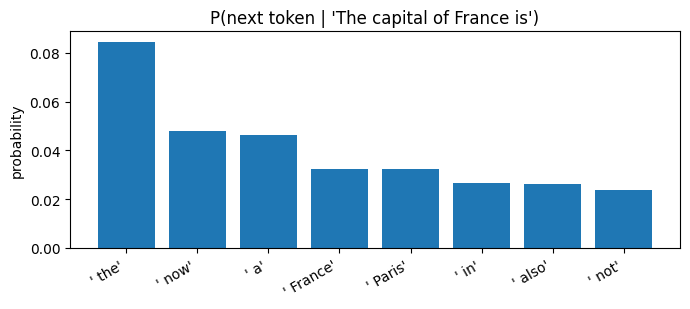

Most likely next token: ' the'


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

if HAS_LM:
    prompt = "The capital of France is"
    ids = tok(prompt, return_tensors="pt").input_ids
    with torch.no_grad():
        logits = lm(ids).logits[0, -1]          # logits for the next token only
    probs = F.softmax(logits, dim=-1)
    topk = torch.topk(probs, 8)
    labels = [repr(tok.decode([i])) for i in topk.indices]

    plt.figure(figsize=(7, 3.2))
    plt.bar(labels, topk.values.numpy())
    plt.title(f"P(next token | {prompt!r})")
    plt.ylabel("probability"); plt.xticks(rotation=30, ha="right")
    plt.tight_layout(); plt.show()
    print("Most likely next token:", repr(tok.decode([topk.indices[0]])))

*The model concentrates probability on ' Paris' (and a few plausible alternatives). Generation is choosing from this distribution — and *how* we choose is the next topic.*

## Temperature: the creativity dial

Before sampling, we can divide the logits by a **temperature** T:

- **T → 0**: the distribution collapses onto the single most likely token → deterministic, repetitive, "safe."
- **T = 1**: the model's natural distribution.
- **T > 1**: flattens the distribution → more surprising, more creative, more error-prone.

Let's visualize the *same* logits at three temperatures.

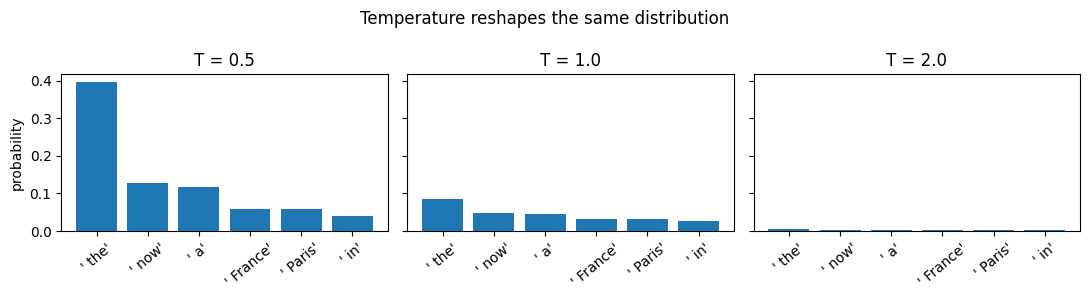

In [3]:
if HAS_LM:
    def softmax_with_temperature(logits, T):
        return F.softmax(logits / T, dim=-1)

    fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
    for ax, T in zip(axes, [0.5, 1.0, 2.0]):
        p = softmax_with_temperature(logits, T)
        tk = torch.topk(p, 6)
        ax.bar([repr(tok.decode([i])) for i in tk.indices], tk.values.numpy())
        ax.set_title(f"T = {T}"); ax.tick_params(axis="x", rotation=40)
    axes[0].set_ylabel("probability")
    plt.suptitle("Temperature reshapes the same distribution")
    plt.tight_layout(); plt.show()

*Low temperature sharpens the peak (the model 'commits'); high temperature spreads probability to the long tail (the model 'explores'). Same logits, different risk appetite.*

## Decoding strategies in action

- **Greedy**: always take the argmax. Coherent but repetitive.
- **Sampling with temperature**: draw randomly from the (reshaped) distribution.
- **Top-k**: sample only from the k most likely tokens.
- **Top-p (nucleus)**: sample from the smallest set of tokens whose probability sums to p.

`model.generate` exposes all of these. Watch how the style changes.

In [4]:
if HAS_LM:
    torch.manual_seed(0)
    prompt = "In the year 2045, artificial intelligence"
    ids = tok(prompt, return_tensors="pt").input_ids

    configs = {
        "greedy            ": dict(do_sample=False),
        "temp=0.7, top_p=.9": dict(do_sample=True, temperature=0.7, top_p=0.9),
        "temp=1.3, top_k=50": dict(do_sample=True, temperature=1.3, top_k=50),
    }
    for name, cfg in configs.items():
        out = lm.generate(ids, max_new_tokens=30, pad_token_id=tok.eos_token_id, **cfg)
        text = tok.decode(out[0], skip_special_tokens=True)
        print(f"[{name}] {text}\n")

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


[greedy            ] In the year 2045, artificial intelligence will be the dominant technology in the world.

The future of artificial intelligence is in the hands of the next generation of AI.

The



[temp=0.7, top_p=.9] In the year 2045, artificial intelligence will be the dominant technology in the world, according to the Center for Strategic and International Studies, a Washington-based think tank.

The future



[temp=1.3, top_k=50] In the year 2045, artificial intelligence will begin gathering in a large swath of the global computer economy. That will continue its efforts to improve its capabilities as it grows its own workforce and in



## The context window

The model can only condition on the tokens currently in its **context window** (GPT-2: 1024 tokens; modern models: 100k–1M+). Anything outside it simply doesn't exist for the model — no long-term memory, no awareness of earlier conversation once it scrolls off. This hard limit is why we need **prompt engineering** (notebook 12), the **KV cache** (notebook 13), and **RAG** (notebook 14) to feed the right tokens into that finite window.

In [5]:
if HAS_LM:
    print("GPT-2 context window:", lm.config.n_positions, "tokens")
    long_prompt = "word " * 1100                 # deliberately too long
    n = len(tok(long_prompt).input_ids)
    print(f"A {n}-token prompt would OVERFLOW the window and must be truncated or chunked.")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1101 > 1024). Running this sequence through the model will result in indexing errors


GPT-2 context window: 1024 tokens
A 1101-token prompt would OVERFLOW the window and must be truncated or chunked.


## Why LLMs hallucinate

Here's the punchline of Tier 1. The model predicts **plausible** tokens, not **true** ones. It has no database to check facts against — it has statistical patterns. When you ask about something rare or fictional, the most *plausible-sounding* continuation is often confidently wrong. Watch GPT-2 invent "facts" about a made-up product.

In [6]:
if HAS_LM:
    torch.manual_seed(1)
    fake = "The Helios Robotics HX-9000 quantum gripper was first released in the year"
    ids = tok(fake, return_tensors="pt").input_ids
    out = lm.generate(ids, max_new_tokens=25, do_sample=True, temperature=0.8,
                      top_p=0.9, pad_token_id=tok.eos_token_id)
    print(tok.decode(out[0], skip_special_tokens=True))
    print("\nThe HX-9000 does not exist — yet the model fills in a confident, fluent answer.")
    print("It is optimizing for plausibility, not truth. This is WHY we build RAG and evals.")

The Helios Robotics HX-9000 quantum gripper was first released in the year 2002. Since then, the company has made a number of new designs, including the Helios HX-1 robot that

The HX-9000 does not exist — yet the model fills in a confident, fluent answer.
It is optimizing for plausibility, not truth. This is WHY we build RAG and evals.


## Exercises

In [7]:
# Exercise 1 (Warm-up): Sweep the temperature
# Task: Generate from the same prompt at temperature 0.2, 0.8, and 1.5 (do_sample=True).
#       Describe how coherence and creativity trade off.
# Hint: Very low T repeats; very high T degenerates into word salad. There's a sweet spot.

# YOUR CODE HERE

In [8]:
# Exercise 2 (Apply): Top-k sampling from scratch
# Task: Write top_k_sample(logits, k, T) that (a) applies temperature, (b) keeps only the k
#       largest logits (set the rest to -inf), (c) softmaxes, (d) samples one token id.
#       Use it to generate 20 tokens in a manual loop and decode the result.
# Hint: torch.topk gives indices to keep; torch.multinomial(probs, 1) draws a sample.

# YOUR CODE HERE

In [9]:
# Exercise 3 (Extend): Hallucination -> RAG
# Task: Take the HX-9000 prompt and PREPEND a short factual 'context' paragraph you write
#       (e.g. 'Context: The HX-9000 was released in 2099 and lifts 12 kg.'). Generate again.
#       Does grounding the prompt change the answer? This previews RAG (notebook 14).
# Hint: LLMs attend strongly to recent context; giving them facts up front steers the output.

# YOUR CODE HERE

<details>
<summary>Show solutions</summary>

```python
# Exercise 2
def top_k_sample(logits, k=10, T=1.0):
    logits = logits / T
    vals, idx = torch.topk(logits, k)
    filtered = torch.full_like(logits, float("-inf"))
    filtered[idx] = vals
    probs = F.softmax(filtered, dim=-1)
    return torch.multinomial(probs, 1)

ids = tok("Once upon a time", return_tensors="pt").input_ids
for _ in range(20):
    with torch.no_grad():
        nxt = top_k_sample(lm(ids).logits[0, -1], k=10, T=0.9)
    ids = torch.cat([ids, nxt[None, :]], dim=1)
print(tok.decode(ids[0]))

# Exercise 3: prepend 'Context: ...' — the generation now tends to echo your supplied facts.
```
</details>

## Key Takeaways
- An LLM is a **next-token predictor**; generation is that prediction looped, appending one token at a time.
- **Temperature** sharpens (low) or flattens (high) the distribution; **top-k / top-p** restrict sampling to the likely tokens.
- The **context window** is a hard limit on what the model can condition on — the root reason for prompt engineering, KV caching, and RAG.
- **Hallucination** is intrinsic: the model optimizes for *plausible* continuations, not *true* ones. Fixing it means changing the inputs (RAG) or measuring outputs (evals), not the sampler.

## What's Next
You've finished **Tier 1 — Foundations**. Tier 2 opens with notebook **07 — Pretraining & Scaling Laws**: where these next-token predictors get their knowledge, and why bigger + more data reliably means better.